#### Tarea 2
## Notebook Preprocesamiento: Breast Cancer Wisconsin dataset
En la presente tarea se hará uso del dataset **Breast Cancer Wisconsin**, con el objetivo de aplicar dos de los métodos de procesamiento de datos vistos en clase.

El dataset contiene información obtenida a partir de muestras celulares de pacientes con tumores de mama. Cuenta con un total de 699 instancias y 11 atributos, los cuales describen diferentes características de las células analizadas. Los atributos que conforman el dataset son los siguientes: 
| # | Attribute | Values / Description |
|---|---|---|
| 1 | Sample Code Number | ID number |
| 2 | Clump Thickness | 1–10 |
| 3 | Uniformity of Cell Size | 1–10 |
| 4 | Uniformity of Cell Shape | 1–10 |
| 5 | Marginal Adhesion | 1–10 |
| 6 | Single Epithelial Cell Size | 1–10 |
| 7 | Bare Nuclei | 1–10 |
| 8 | Bland Chromatin | 1–10 |
| 9 | Normal Nucleoli | 1–10 |
| 10 | Mitoses | 1–10 |
| 11 | Class | 2 = Benign, 4 = Malignant |

Como se puede observar, la variable objetivo del dataset es **Class**, la cual corresponde a una variable categórica utilizada para clasificar las muestras analizadas. El valor 2 representa los casos benignos, mientras que el valor 4 representa los casos malignos de cáncer de mama.

### Librerias

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

### Procesamiento del dataset
#### Limpieza 

In [11]:
#El dataset no contiene nombres de columnas, por lo que se agregó manualmente.
column_names = [
    "Sample code number",
    "Clump Thickness",
    "Uniformity of Cell Size",
    "Uniformity of Cell Shape",
    "Marginal Adhesion",
    "Single Epithelial Cell Size",
    "Bare Nuclei",
    "Bland Chromatin",
    "Normal Nucleoli",
    "Mitoses",
    "Class",
] 

df = pd.read_csv(
    "breast-cancer-wisconsin.data",
    names=column_names,
)
describe = df.describe()
describe

,Sample code number,Clump Thickness,Uniformity of Cell Size,Uniformity of Cell Shape,Marginal Adhesion,Single Epithelial Cell Size,Bland Chromatin,Normal Nucleoli,Mitoses,Class
count,6.990000e+02,699.000000,699.000000,699.000000,699.000000,699.000000,699.000000,699.000000,699.000000,699.000000
mean,1.071704e+06,4.417740,3.134478,3.207439,2.806867,3.216023,3.437768,2.866953,1.589413,2.689557
std,6.170957e+05,2.815741,3.051459,2.971913,2.855379,2.214300,2.438364,3.053634,1.715078,0.951273
min,6.163400e+04,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,2.000000
25%,8.706885e+05,2.000000,1.000000,1.000000,1.000000,2.000000,2.000000,1.000000,1.000000,2.000000
50%,1.171710e+06,4.000000,1.000000,1.000000,1.000000,2.000000,3.000000,1.000000,1.000000,2.000000
75%,1.238298e+06,6.000000,5.000000,5.000000,4.000000,4.000000,5.000000,4.000000,1.000000,4.000000
max,1.345435e+07,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,4.000000


Como se puede observar el atributo *Bare Nuclei* no aparece como numérica, aunque debería contener valores de 1 a 10. Esto ocurre ya que los datos faltantes en este atributo están representados mediante ?, no como NaN, lo que proboca que Pandas interprete toda la columna como texto. En la siguiente gráfica se puede apreciar la cantidad de datos faltantes.

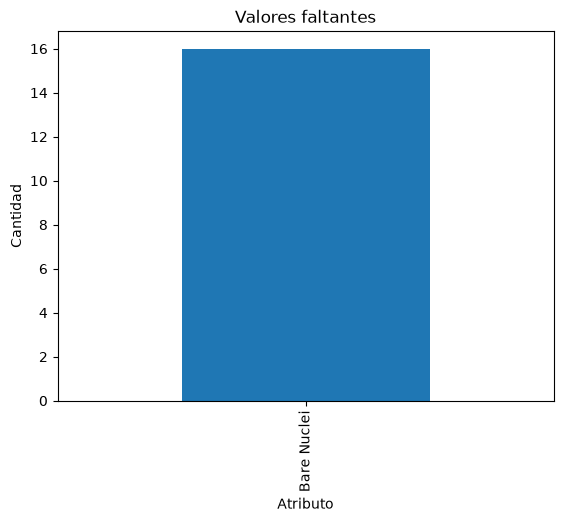

In [12]:
valores_faltantes = (df == '?').sum() #los datos faltantes están representados por el símbolo ?
valores_faltantes[valores_faltantes > 0].plot(kind='bar')
plt.title('Valores faltantes')
plt.ylabel('Cantidad')
plt.xlabel('Atributo')
plt.show()

Lo que se puede hacer es convertir los valores faltantes ? a Nan y de ahi convertir la variable a númerica

In [13]:
bare_antes = pd.to_numeric(df['Bare Nuclei'].replace('?', np.nan)).copy() #guardamos la columna antes de imputar
df.replace('?', np.nan, inplace=True)
df.isnull().sum() #comprobamos que los valores faltantes se han reemplazado por NaN

Sample code number              0
Clump Thickness                 0
Uniformity of Cell Size         0
Uniformity of Cell Shape        0
Marginal Adhesion               0
Single Epithelial Cell Size     0
Bare Nuclei                    16
Bland Chromatin                 0
Normal Nucleoli                 0
Mitoses                         0
Class                           0
dtype: int64

In [14]:
df['Bare Nuclei'] = pd.to_numeric(df['Bare Nuclei']) #convertimos la columna 'Bare Nuclei' a tipo numérico
describe = df.describe()
describe

,Sample code number,Clump Thickness,Uniformity of Cell Size,Uniformity of Cell Shape,Marginal Adhesion,Single Epithelial Cell Size,Bare Nuclei,Bland Chromatin,Normal Nucleoli,Mitoses,Class
count,6.990000e+02,699.000000,699.000000,699.000000,699.000000,699.000000,683.000000,699.000000,699.000000,699.000000,699.000000
mean,1.071704e+06,4.417740,3.134478,3.207439,2.806867,3.216023,3.544656,3.437768,2.866953,1.589413,2.689557
std,6.170957e+05,2.815741,3.051459,2.971913,2.855379,2.214300,3.643857,2.438364,3.053634,1.715078,0.951273
min,6.163400e+04,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,2.000000
25%,8.706885e+05,2.000000,1.000000,1.000000,1.000000,2.000000,1.000000,2.000000,1.000000,1.000000,2.000000
50%,1.171710e+06,4.000000,1.000000,1.000000,1.000000,2.000000,1.000000,3.000000,1.000000,1.000000,2.000000
75%,1.238298e+06,6.000000,5.000000,5.000000,4.000000,4.000000,6.000000,5.000000,4.000000,1.000000,4.000000
max,1.345435e+07,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,4.000000


De aqui, ahora si toca decidir qué hacer con los valores faltantes. En este caso decidí remplazar los valores faltantes del atributo Bare Nuclei utilizando la mediana de los valores disponibles. Esta medida se eligió debido a que  permite conservar los registros que presentan datos faltantes, evitando eliminar información de los demás atributos. 

In [15]:
mediana = df['Bare Nuclei'].median() #calcular la mediana de la columna 'Bare Nuclei'
print("Mediana:", mediana)
df['Bare Nuclei'] = df['Bare Nuclei'].fillna(mediana) #reemplazamos los valores faltantes con la mediana
df.isnull().sum() #comprobamos que los valores faltantes se han reemplazado

Mediana: 1.0


Sample code number             0
Clump Thickness                0
Uniformity of Cell Size        0
Uniformity of Cell Shape       0
Marginal Adhesion              0
Single Epithelial Cell Size    0
Bare Nuclei                    0
Bland Chromatin                0
Normal Nucleoli                0
Mitoses                        0
Class                          0
dtype: int64

Para hacer la representación gráfica de los datos, podemos utilizar un histograma para visualizar la distribución de la columna *Bare Nuclei* antes y después de reemplazar los valores faltantes con la mediana.

Datos antes: 683
Valores faltantes antes: 16

Datos después: 699
Valores faltantes después: 0


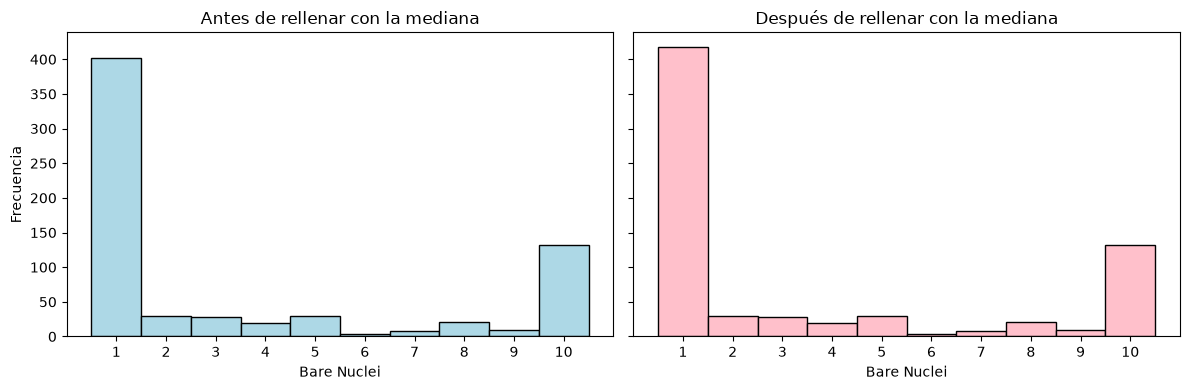

In [23]:
print("Datos antes:", bare_antes.count())
print("Valores faltantes antes:", bare_antes.isna().sum())

print("\nDatos después:", df['Bare Nuclei'].count())
print("Valores faltantes después:", df['Bare Nuclei'].isna().sum())
bins = np.arange(0.5, 11.5, 1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

axes[0].hist(bare_antes.dropna(), bins=bins, color='lightblue', edgecolor='black')
axes[0].set_title('Antes de rellenar con la mediana')
axes[0].set_xlabel('Bare Nuclei')
axes[0].set_ylabel('Frecuencia')
axes[0].set_xticks(range(1, 11))

axes[1].hist(df['Bare Nuclei'], bins=bins, color='pink', edgecolor='black')
axes[1].set_title('Después de rellenar con la mediana')
axes[1].set_xlabel('Bare Nuclei')
axes[1].set_xticks(range(1, 11))

plt.tight_layout()
plt.show()

El uso de la mediana permitió completar los 16 valores faltantes sin tener que eliminar las instancias correspondientes y perder la información de los demás atributos. Debido a que estos valores representan una proporción pequeña del total de datos, el rellenado con la mediana no produjo un cambio considerable en la distribución de Bare Nuclei, pero sí permitió conservar las 699 instancias originales para los análisis posteriores.

#### Reducción de dimensionalidad con PCA